In [9]:
import pandas as pd 

data = pd.read_csv("E:\myntra_dataset.csv")

print(data.head())
print(data.info())

       brand_name           pants_description   price     MRP  \
0           WROGN  Men Loose Fit Cotton Jeans  1374.0  2499.0   
1  Flying Machine          Men Slim Fit Jeans  1829.0  2999.0   
2        Roadster       Men Pure Cotton Jeans   974.0  2499.0   
3      Bene Kleed     Relaxed Fit Denim Jeans   873.0  2299.0   
4           Levis      Men 511 Slim Fit Jeans  1478.0  2899.0   

   discount_percent  ratings  number_of_ratings  
0              0.45      4.2               57.0  
1              0.39      4.6                5.0  
2              0.61      3.6             1100.0  
3              0.62      4.0             4800.0  
4              0.49      4.3              264.0  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52120 entries, 0 to 52119
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand_name         52120 non-null  object 
 1   pants_description  52120 non-null  object 
 2   pric

In [26]:
data = data.drop_duplicates()

data = data.dropna()

data["price"] = data["price"].astype(float)

In [28]:
print(data.columns)


Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings', 'trend_score'],
      dtype='object')


In [35]:
print(data["ratings"].dtype)
print(data["ratings"].head())


float64
0    4.2
1    4.6
2    3.6
3    4.0
4    4.3
Name: ratings, dtype: float64


In [49]:
print(data.dtypes)


brand_name            object
pants_description     object
price                float64
MRP                  float64
discount_percent     float64
ratings              float64
number_of_ratings    float64
trend_score          float64
dtype: object


In [52]:
print(data.columns)
print(data.head)

Index(['brand_name', 'pants_description', 'price', 'MRP', 'discount_percent',
       'ratings', 'number_of_ratings', 'trend_score'],
      dtype='object')
<bound method NDFrame.head of                       brand_name            pants_description   price     MRP  \
0                          WROGN   Men Loose Fit Cotton Jeans  1374.0  2499.0   
1                 Flying Machine           Men Slim Fit Jeans  1829.0  2999.0   
2                       Roadster        Men Pure Cotton Jeans   974.0  2499.0   
3                     Bene Kleed      Relaxed Fit Denim Jeans   873.0  2299.0   
4                          Levis       Men 511 Slim Fit Jeans  1478.0  2899.0   
...                          ...                          ...     ...     ...   
52010  United Colors of Benetton  Men Slim Fit Mid-Rise Jeans   949.0  3049.0   
52013                   HERE&NOW           Men Slim Fit Jeans   759.0  1899.0   
52014                 Pepe Jeans    Men Vapour Slim Fit Jeans   759.0  1899.0   
52015

In [53]:
print(data.head())

       brand_name           pants_description   price     MRP  \
0           WROGN  Men Loose Fit Cotton Jeans  1374.0  2499.0   
1  Flying Machine          Men Slim Fit Jeans  1829.0  2999.0   
2        Roadster       Men Pure Cotton Jeans   974.0  2499.0   
3      Bene Kleed     Relaxed Fit Denim Jeans   873.0  2299.0   
4           Levis      Men 511 Slim Fit Jeans  1478.0  2899.0   

   discount_percent  ratings  number_of_ratings  trend_score  
0              0.45      4.2               57.0     0.003057  
1              0.39      4.6                5.0     0.002515  
2              0.61      3.6             1100.0     0.003696  
3              0.62      4.0             4800.0     0.004582  
4              0.49      4.3              264.0     0.002909  


In [56]:
data["ratings"].astype(float)

0        4.2
1        4.6
2        3.6
3        4.0
4        4.3
        ... 
52010    3.8
52013    4.0
52014    4.0
52015    4.0
52018    4.0
Name: ratings, Length: 35073, dtype: float64

In [71]:
print(data[["ratings", "number_of_ratings", "discount_percent", "trend_score"]].head())

   ratings  number_of_ratings  discount_percent  trend_score
0      4.2               57.0              0.45     0.078406
1      4.6                5.0              0.39     0.004904
2      3.6             1100.0              0.61     2.480082
3      4.0             4800.0              0.62    13.635739
4      4.3              264.0              0.49     0.376352


In [74]:
print(data.sort_values("trend_score", ascending=False).head(10))

                      brand_name               pants_description  price  \
39520  United Colors of Benetton  Men Mid-Rise Regular Fit Jeans  579.0   
39519                   Roadster              Men Slim Fit Jeans  579.0   
28991                   Roadster            Men Skinny Fit Jeans  479.0   
36                Urbano Fashion              Men Slim Fit Jeans  629.0   
11073                 HIGHLANDER              Men Slim Fit Jeans  584.0   
11552                 HIGHLANDER           Men Tapered Fit Jeans  493.0   
32602                 HIGHLANDER              Men Slim Fit Jeans  519.0   
28887                   Roadster            Men Skinny Fit Jeans  874.0   
28395                 HIGHLANDER              Men Slim Fit Jeans  623.0   
28471                 HIGHLANDER           Men Tapered Fit Jeans  594.0   

          MRP  discount_percent  ratings  number_of_ratings  trend_score  \
39520  1999.0              0.71      3.5            30700.0   131.760794   
39519  1999.0         

In [75]:
data["discount_percent"] = data["discount_percent"].apply(
    lambda x: x/100 if x > 1 else x
)

print(data["discount_percent"].describe())

count    35073.000000
mean         0.468419
std          0.184036
min          0.011000
25%          0.380000
50%          0.500000
75%          0.600000
max          1.000000
Name: discount_percent, dtype: float64


In [76]:
data["trend_score"] = (
    data["ratings"] *
    data["number_of_ratings"] *
    data["discount_percent"]
) / data["price"]

print(data["trend_score"].describe())

count    35073.000000
mean         0.230913
std          1.922349
min          0.000053
25%          0.014552
50%          0.040228
75%          0.114168
max        131.760794
Name: trend_score, dtype: float64


In [78]:
import numpy as np

data["trend_score"] = np.log1p(data["trend_score"])

print(data["trend_score"].describe())

count    35073.000000
mean         0.117748
std          0.272085
min          0.000053
25%          0.014447
50%          0.039440
75%          0.108108
max          4.888549
Name: trend_score, dtype: float64


In [79]:
threshold = data["trend_score"].quantile(0.75)
data["trending"] = data["trend_score"] > threshold

print("Threshold:", threshold)
print(data["trending"].value_counts())

Threshold: 0.10810797352139602
trending
False    26305
True      8768
Name: count, dtype: int64


In [80]:
print(data[["brand_name", "pants_description", "price", "ratings", "number_of_ratings", "trend_score"]].sort_values("trend_score", ascending=False).head(10))

                      brand_name               pants_description  price  \
39520  United Colors of Benetton  Men Mid-Rise Regular Fit Jeans  579.0   
39519                   Roadster              Men Slim Fit Jeans  579.0   
28991                   Roadster            Men Skinny Fit Jeans  479.0   
36                Urbano Fashion              Men Slim Fit Jeans  629.0   
11073                 HIGHLANDER              Men Slim Fit Jeans  584.0   
11552                 HIGHLANDER           Men Tapered Fit Jeans  493.0   
32602                 HIGHLANDER              Men Slim Fit Jeans  519.0   
28887                   Roadster            Men Skinny Fit Jeans  874.0   
28395                 HIGHLANDER              Men Slim Fit Jeans  623.0   
28471                 HIGHLANDER           Men Tapered Fit Jeans  594.0   

       ratings  number_of_ratings  trend_score  
39520      3.5            30700.0     4.888549  
39519      3.5            30700.0     4.888549  
28991      3.9            2

In [77]:
print(data.sort_values("trend_score", ascending=False).head(10))

                      brand_name               pants_description  price  \
39520  United Colors of Benetton  Men Mid-Rise Regular Fit Jeans  579.0   
39519                   Roadster              Men Slim Fit Jeans  579.0   
28991                   Roadster            Men Skinny Fit Jeans  479.0   
36                Urbano Fashion              Men Slim Fit Jeans  629.0   
11073                 HIGHLANDER              Men Slim Fit Jeans  584.0   
11552                 HIGHLANDER           Men Tapered Fit Jeans  493.0   
32602                 HIGHLANDER              Men Slim Fit Jeans  519.0   
28887                   Roadster            Men Skinny Fit Jeans  874.0   
28395                 HIGHLANDER              Men Slim Fit Jeans  623.0   
28471                 HIGHLANDER           Men Tapered Fit Jeans  594.0   

          MRP  discount_percent  ratings  number_of_ratings  trend_score  \
39520  1999.0              0.71      3.5            30700.0   131.760794   
39519  1999.0         

In [81]:
print("Threshold:", data["trend_score"].quantile(0.75))
print(data["trending"].value_counts())

Threshold: 0.10810797352139602
trending
False    26305
True      8768
Name: count, dtype: int64


In [82]:
features = data[["price", "MRP", "discount_percent", "ratings", "number_of_ratings", "trending"]].copy()

features = features.dropna()

print(features.shape)
print(features["trending"].value_counts())

(35073, 6)
trending
False    26305
True      8768
Name: count, dtype: int64


In [83]:
from sklearn.model_selection import train_test_split

X = features.drop("trending", axis=1)
y = features["trending"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training size:", X_train.shape)
print("Testing size:", X_test.shape)

Training size: (28058, 5)
Testing size: (7015, 5)


In [84]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("Model trained ✅")

Model trained ✅


In [85]:
from sklearn.metrics import accuracy_score, classification_report

predictions = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions))
print("\n", classification_report(y_test, predictions))

Accuracy: 0.9938702779757662

               precision    recall  f1-score   support

       False       1.00      1.00      1.00      5262
        True       0.99      0.99      0.99      1753

    accuracy                           0.99      7015
   macro avg       0.99      0.99      0.99      7015
weighted avg       0.99      0.99      0.99      7015



In [86]:
features2 = data[["price", "MRP", "discount_percent", "ratings", "trending"]].copy()
features2 = features2.dropna()

X = features2.drop("trending", axis=1)
y = features2["trending"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model2 = RandomForestClassifier(n_estimators=100, random_state=42)
model2.fit(X_train, y_train)

predictions2 = model2.predict(X_test)

print("Accuracy:", accuracy_score(y_test, predictions2))
print("\n", classification_report(y_test, predictions2))

Accuracy: 0.8369208838203849

               precision    recall  f1-score   support

       False       0.88      0.90      0.89      5262
        True       0.69      0.63      0.66      1753

    accuracy                           0.84      7015
   macro avg       0.78      0.77      0.78      7015
weighted avg       0.83      0.84      0.83      7015



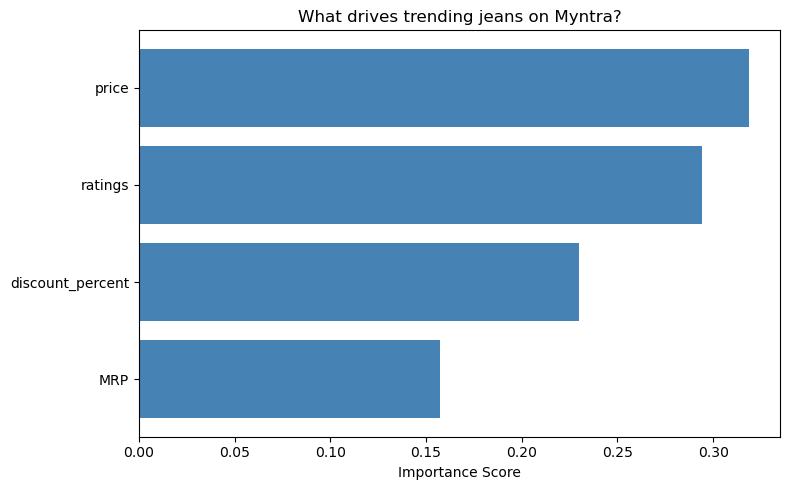

            Feature  Importance
0             price    0.318958
3           ratings    0.294090
2  discount_percent    0.229668
1               MRP    0.157283


In [87]:
import matplotlib.pyplot as plt
import pandas as pd

feature_names = ["price", "MRP", "discount_percent", "ratings"]
importances = model2.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 5))
plt.barh(importance_df["Feature"], importance_df["Importance"], color="steelblue")
plt.xlabel("Importance Score")
plt.title("What drives trending jeans on Myntra?")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("feature_importance.png")
plt.show()

print(importance_df)

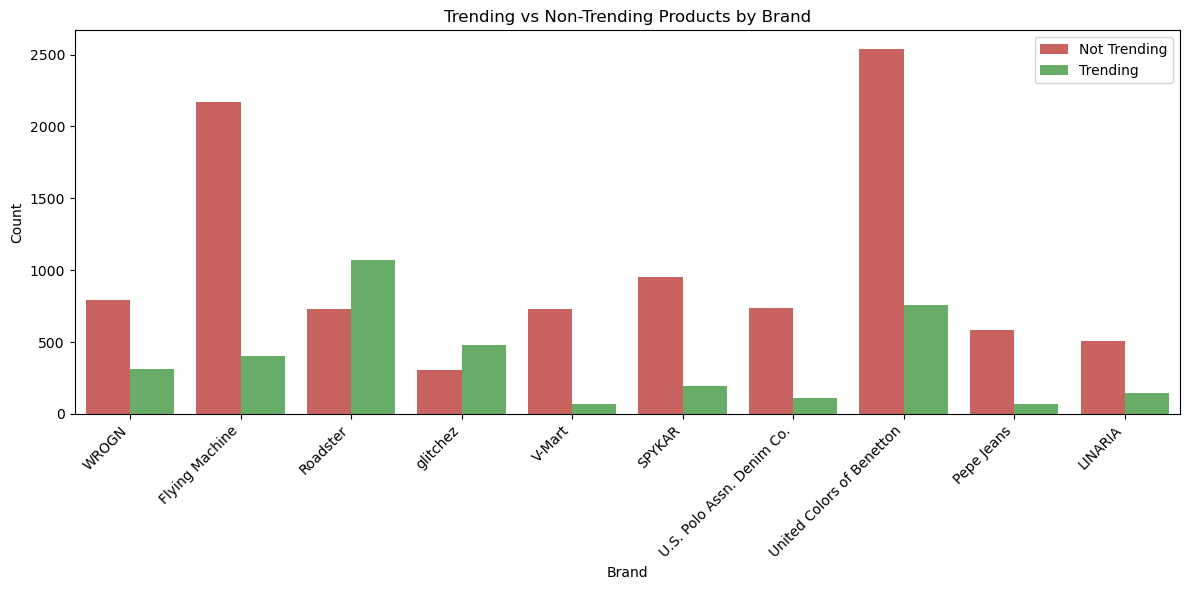

In [88]:
import matplotlib.pyplot as plt
import seaborn as sns

top_brands = data["brand_name"].value_counts().head(10).index
brand_data = data[data["brand_name"].isin(top_brands)]

plt.figure(figsize=(12, 6))
sns.countplot(data=brand_data, x="brand_name", hue="trending",
              palette=["#d9534f", "#5cb85c"])
plt.xticks(rotation=45, ha="right")
plt.title("Trending vs Non-Trending Products by Brand")
plt.xlabel("Brand")
plt.ylabel("Count")
plt.legend(labels=["Not Trending", "Trending"])
plt.tight_layout()
plt.savefig("brand_trending.png")
plt.show()

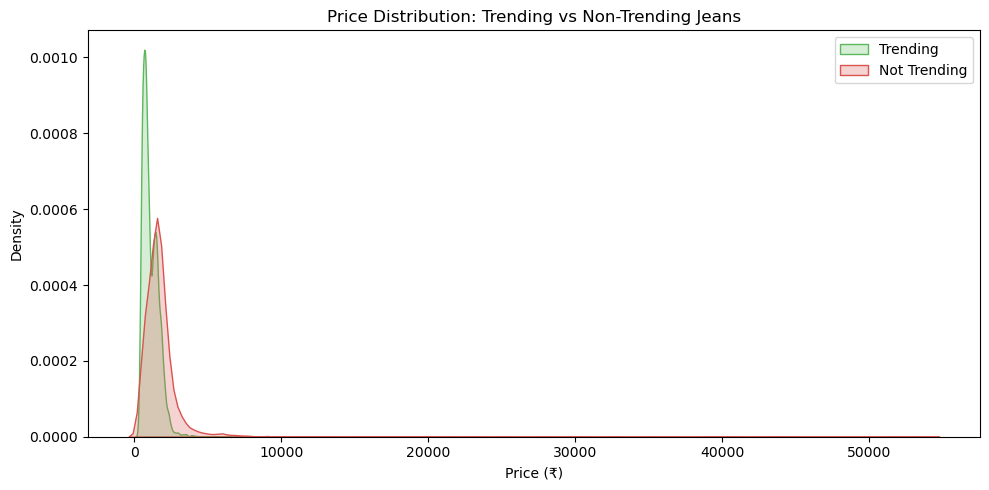

In [89]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=data[data["trending"]==True]["price"],
            label="Trending", fill=True, color="#5cb85c")
sns.kdeplot(data=data[data["trending"]==False]["price"],
            label="Not Trending", fill=True, color="#d9534f")
plt.title("Price Distribution: Trending vs Non-Trending Jeans")
plt.xlabel("Price (₹)")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.savefig("price_distribution.png")
plt.show()

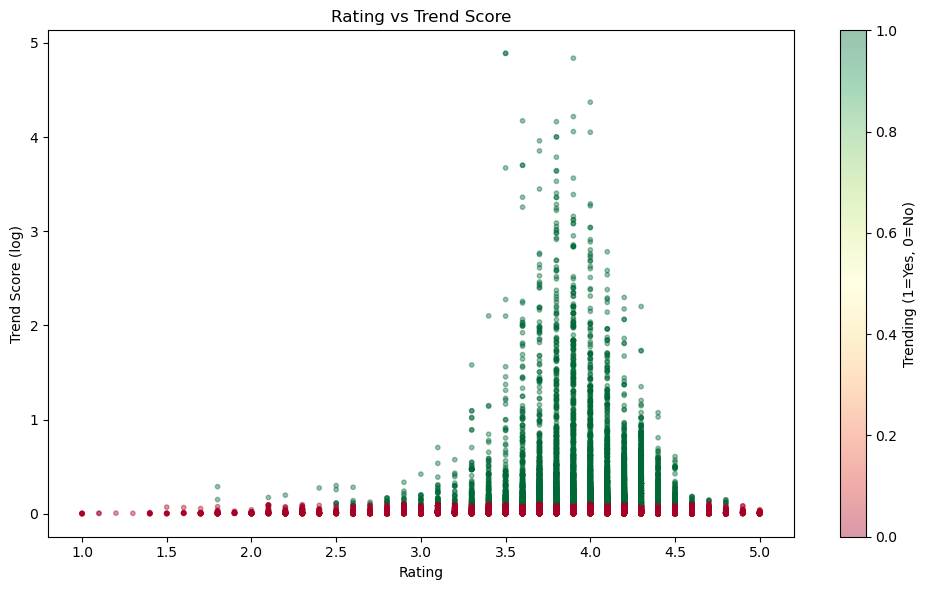

In [90]:
plt.figure(figsize=(10, 6))
scatter = plt.scatter(data["ratings"], data["trend_score"],
                      c=data["trending"].astype(int),
                      cmap="RdYlGn", alpha=0.4, s=10)
plt.colorbar(scatter, label="Trending (1=Yes, 0=No)")
plt.xlabel("Rating")
plt.ylabel("Trend Score (log)")
plt.title("Rating vs Trend Score")
plt.tight_layout()
plt.savefig("rating_vs_trend.png")
plt.show()

In [91]:
insight = data.groupby("trending").agg(
    avg_price=("price", "mean"),
    avg_rating=("ratings", "mean"),
    avg_discount=("discount_percent", "mean")
).round(2)

print("=== KEY BUSINESS INSIGHTS ===")
print(insight)

=== KEY BUSINESS INSIGHTS ===
          avg_price  avg_rating  avg_discount
trending                                     
False       1796.47        3.96          0.44
True        1083.16        4.02          0.56
